# 03 — Baseline Fall Detector: LR + RF (LOSO)

**Tarea B2** — Baseline binario antes del CNN para justificar la arquitectura profunda.

- Features manuales: pico SVM, energía, duración del impacto, varianza post-caída
- Logistic Regression + Random Forest en validación LOSO (38 sujetos)
- Métricas: Recall, Precision, F1, AUC-ROC (énfasis en **recall** — FN es el peor error)

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.windowing import resample, compute_svm, detect_impact_peaks

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

SISFALL_DIR = DATA_RAW / 'SisFall_dataset'
SISFALL_HZ  = 200
ADXL345_FACTOR = (2 * 16) / (2 ** 13)
ITG3200_FACTOR  = (2 * 2000) / (2 ** 16)

## 1. Carga de datos SisFall

In [2]:
def load_sisfall_file(filepath: Path) -> np.ndarray | None:
    try:
        text = filepath.read_text().replace(';', '')
        raw = np.genfromtxt(io.StringIO(text), delimiter=',', dtype=np.float32)
    except Exception:
        return None
    if raw.ndim != 2 or raw.shape[1] < 6:
        return None
    accel = raw[:, 0:3] * ADXL345_FACTOR
    gyro  = raw[:, 3:6] * ITG3200_FACTOR
    return np.concatenate([accel, gyro], axis=1).astype(np.float32)


def load_sisfall_dataset(base_dir: Path) -> pd.DataFrame:
    records = []
    for subj_dir in sorted(base_dir.iterdir()):
        if not subj_dir.is_dir():
            continue
        for txt_file in sorted(subj_dir.glob('*.txt')):
            parts = txt_file.stem.split('_')
            if len(parts) < 3:
                continue
            code, subject = parts[0], parts[1]
            data = load_sisfall_file(txt_file)
            if data is None:
                continue
            data_50 = resample(data, orig_hz=SISFALL_HZ, target_hz=50)
            records.append({
                'data': data_50,
                'is_fall': code.startswith('F'),
                'code': code,
                'subject': subject,
                'age_group': 'elderly' if subject.startswith('SE') else 'young_adult',
            })
    return pd.DataFrame(records)


print("Loading SisFall...")
df = load_sisfall_dataset(SISFALL_DIR)
print(f"Loaded {len(df)} recordings | Falls: {df.is_fall.sum()} | ADL: {(~df.is_fall).sum()}")
print(f"Subjects: {df.subject.nunique()}")

Loading SisFall...


Loaded 4505 recordings | Falls: 1798 | ADL: 2707
Subjects: 38


## 2. Extracción de Features

Features manuales por grabación (sin aprendizaje de representaciones):

| Feature | Descripción |
|---------|-------------|
| `peak_svm` | Máximo de √(ax²+ay²+az²) durante la ventana |
| `mean_svm` | Media del SVM |
| `energy` | Energía media de acelerómetro |
| `impact_duration` | Fracción de muestras con SVM > 2g |
| `post_fall_var` | Varianza del SVM en los últimos 25 samples (inmovilidad) |
| `svm_std` | Desviación estándar del SVM |
| `rise_rate` | Gradiente máximo del SVM (rapidez del impacto) |

In [3]:
def extract_features(data: np.ndarray) -> np.ndarray:
    """Extract handcrafted features from (N, 6) window."""
    accel = data[:, :3]
    svm = compute_svm(accel)

    peak_svm        = float(svm.max())
    mean_svm        = float(svm.mean())
    energy          = float(np.mean(accel ** 2))
    impact_duration = float(np.mean(svm > 2.0))
    post_fall_var   = float(np.var(svm[-25:]))
    svm_std         = float(svm.std())
    gradient        = np.diff(svm)
    rise_rate       = float(gradient.max()) if len(gradient) > 0 else 0.0

    return np.array([
        peak_svm, mean_svm, energy,
        impact_duration, post_fall_var, svm_std, rise_rate
    ], dtype=np.float32)


FEATURE_NAMES = [
    'peak_svm', 'mean_svm', 'energy',
    'impact_duration', 'post_fall_var', 'svm_std', 'rise_rate'
]

print("Extracting features...")
X = np.array([extract_features(row['data']) for _, row in df.iterrows()])
y = df['is_fall'].astype(int).values
subjects = df['subject'].values

print(f"Feature matrix: {X.shape}  |  Classes: {np.bincount(y)}")

# Feature distributions
df_feat = pd.DataFrame(X, columns=FEATURE_NAMES)
df_feat['is_fall'] = y
print("\nFeature means by class:")
print(df_feat.groupby('is_fall')[FEATURE_NAMES].mean().round(3))

Extracting features...


Feature matrix: (4505, 7)  |  Classes: [2707 1798]

Feature means by class:
         peak_svm  mean_svm  energy  impact_duration  post_fall_var  svm_std  \
is_fall                                                                        
0           2.173     1.019   0.367            0.011          0.025    0.161   
1           5.776     1.022   0.384            0.011          0.000    0.301   

         rise_rate  
is_fall             
0            0.864  
1            2.892  


## 3. LOSO Cross-Validation

In [4]:
from sklearn.base import clone

unique_subjects = sorted(np.unique(subjects))
print(f"LOSO: {len(unique_subjects)} folds")

results = {name: [] for name in ['LR', 'RF']}
all_probs = {'LR': [], 'RF': []}
all_true  = []

model_templates = {
    'LR': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
    ]),
    'RF': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    )
}

for subj in unique_subjects:
    test_mask  = subjects == subj
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    if y_test.sum() == 0:
        continue

    all_true.extend(y_test.tolist())

    for name, template in model_templates.items():
        m = clone(template)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        y_prob = m.predict_proba(X_test)[:, 1]

        results[name].append({
            'subject': subj,
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'f1':        f1_score(y_test, y_pred, zero_division=0),
        })
        all_probs[name].extend(y_prob.tolist())

print("LOSO complete.")

for name in ['LR', 'RF']:
    df_res = pd.DataFrame(results[name])
    auc = roc_auc_score(all_true, all_probs[name])
    print(f"\n{name}:")
    print(f"  Recall:    {df_res.recall.mean():.3f} +/- {df_res.recall.std():.3f}")
    print(f"  Precision: {df_res.precision.mean():.3f} +/- {df_res.precision.std():.3f}")
    print(f"  F1:        {df_res.f1.mean():.3f} +/- {df_res.f1.std():.3f}")
    print(f"  AUC-ROC:   {auc:.3f}")


LOSO: 38 folds


LOSO complete.

LR:
  Recall:    0.885 +/- 0.115
  Precision: 0.884 +/- 0.057
  F1:        0.879 +/- 0.072
  AUC-ROC:   0.959

RF:
  Recall:    0.931 +/- 0.072
  Precision: 0.955 +/- 0.047
  F1:        0.941 +/- 0.046
  AUC-ROC:   0.986


## 4. Curvas ROC y PR

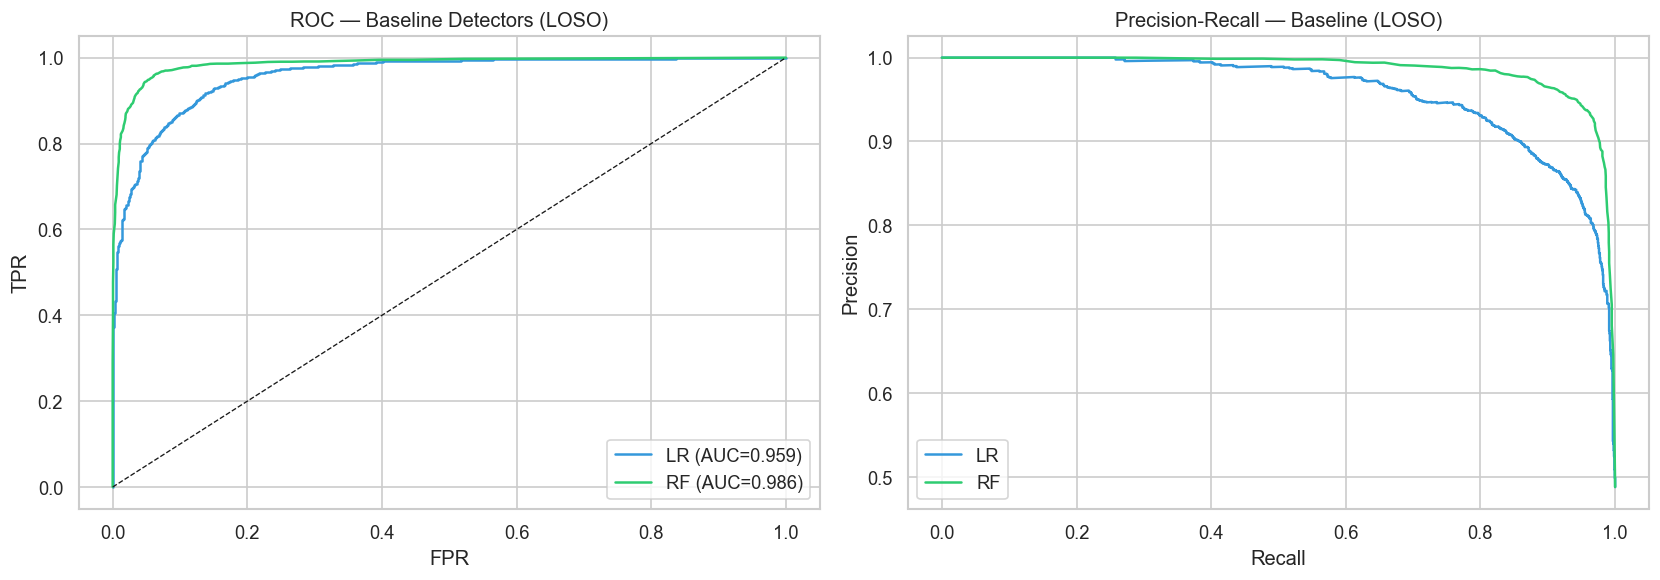

In [5]:
colors = {'LR': '#3498db', 'RF': '#2ecc71'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in ['LR', 'RF']:
    auc = roc_auc_score(all_true, all_probs[name])
    fpr, tpr, _ = roc_curve(all_true, all_probs[name])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[name])

    prec, rec, _ = precision_recall_curve(all_true, all_probs[name])
    axes[1].plot(rec, prec, label=f'{name}', color=colors[name])

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Baseline Detectors (LOSO)')
axes[0].legend()

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — Baseline (LOSO)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/baseline_roc_pr.png', bbox_inches='tight')
plt.show()

## 5. Feature Importances (RF)

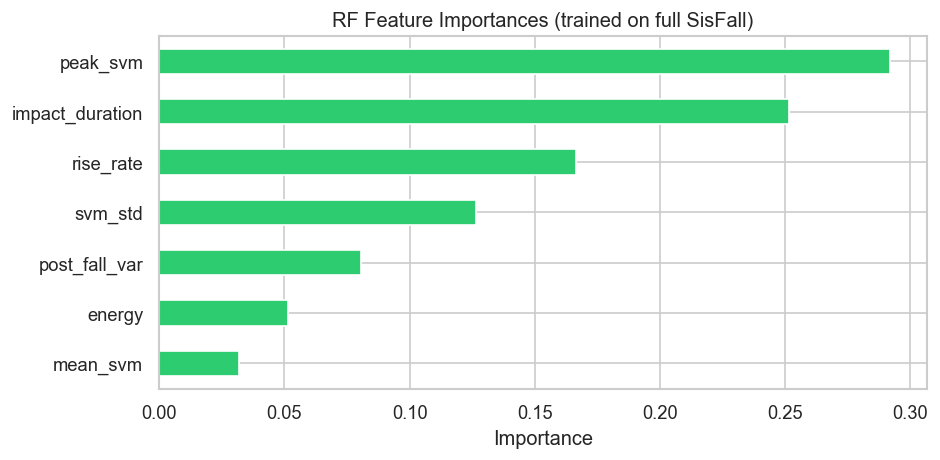


Top features:
peak_svm           0.291946
impact_duration    0.251650
rise_rate          0.166266
svm_std            0.126436
post_fall_var      0.080426
energy             0.051338
mean_svm           0.031937


In [6]:
from sklearn.base import clone

rf_full = clone(model_templates['RF'])
rf_full.fit(X, y)

importances = pd.Series(rf_full.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_title('RF Feature Importances (trained on full SisFall)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/processed/baseline_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop features:")
print(importances[::-1].to_string())


## 6. Resumen — Por qué se necesita CNN

Los modelos baseline usan features manuales diseñadas a mano y evaluados en LOSO. Los resultados
motivan la arquitectura CNN que aprende representaciones directamente de la señal bruta.

In [7]:
print("=" * 60)
print("RESUMEN BASELINE vs CNN (motivación arquitectura profunda)")
print("=" * 60)

for name in ['LR', 'RF']:
    df_res = pd.DataFrame(results[name])
    auc = roc_auc_score(all_true, all_probs[name])
    print(f"\n{name} (LOSO):")
    print(f"  Recall mean:  {df_res.recall.mean():.3f}")
    print(f"  F1 mean:      {df_res.f1.mean():.3f}")
    print(f"  AUC-ROC:      {auc:.3f}")

print()
print("CNN 1D (notebook 04, ver resultados allí):")
print("  → Aprende representaciones temporales sin diseño manual de features")
print("  → Mejor generalización en el overlap SVM {3-5g} donde baseline falla")
print("  → Recall objetivo ≥ 0.95 en modo conservador (65+)")
print()
print("Ventaja del baseline: interpretable, sin GPU, útil como etapa 1 de la cascada.")
print("Limitación: no captura dinámica temporal del impacto → FP en actividades vigorosas.")

RESUMEN BASELINE vs CNN (motivación arquitectura profunda)

LR (LOSO):
  Recall mean:  0.885
  F1 mean:      0.879
  AUC-ROC:      0.959

RF (LOSO):
  Recall mean:  0.931
  F1 mean:      0.941
  AUC-ROC:      0.986

CNN 1D (notebook 04, ver resultados allí):
  → Aprende representaciones temporales sin diseño manual de features
  → Mejor generalización en el overlap SVM {3-5g} donde baseline falla
  → Recall objetivo ≥ 0.95 en modo conservador (65+)

Ventaja del baseline: interpretable, sin GPU, útil como etapa 1 de la cascada.
Limitación: no captura dinámica temporal del impacto → FP en actividades vigorosas.
